In [1]:
%matplotlib widget

import tqdm
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt


from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER
from bscarlos.detector_v3 import ClusteringDetector_v3
from bscarlos.data_processor_kispi import PatientDataProcessor

In [2]:
data_files = sorted(list(PROCESSED_KISPI_DATA_FOLDER.glob('*.parquet')))
data_attributes = pd.read_csv(PROCESSED_KISPI_DATA_FOLDER / 'data_attributes_kispi.csv').set_index("unique_patient_id")

In [3]:
data_files

[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE008_a1.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a1.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a2.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE026_a1.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE038_a1.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE038_a2.parquet')]

In [4]:
data_attributes

,patient_id,start_datetime,end_sample,sample_rate
unique_patient_id,,,,
SE008_a1,P1,17/04/2012 17:02,19:23.0,256
SE021_a1,P2,01/09/2015 16:06,30:27.0,256
SE021_a2,P3,01/09/2015 16:06,30:27.0,256
SE026_a1,P4,20/05/2014 08:30,40:13.0,256
SE038_a1,P5,23/05/2018 11:05,50:32.0,256
SE038_a2,P6,23/05/2018 11:05,50:32.0,256


In [5]:
data_attributes.index

Index(['SE008_a1', 'SE021_a1', 'SE021_a2', 'SE026_a1', 'SE038_a1', 'SE038_a2'], dtype='object', name='unique_patient_id')

In [6]:
pfile = pq.read_table(data_files[0])
print("Column names: {}".format(pfile.column_names))
print("Schema: {}".format(pfile.schema))

Column names: ['EEG Fp1', 'EEG Fp2', 'EEG F7', 'EEG F3', 'EEG Fz', 'EEG F4', 'EEG F8', 'EEG T3', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG T4', 'EEG T5', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG T6', 'EEG O1', 'EEG O2', '__index_level_0__']
Schema: EEG Fp1: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fp1", "dimension": "uV", "sample_rat' + 210
EEG Fp2: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fp2", "dimension": "uV", "sample_rat' + 210
EEG F7: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F7", "dimension": "uV", "sample_rate' + 209
EEG F3: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F3", "dimension": "uV", "sample_rate' + 209
EEG Fz: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fz", "dimension": "uV", "sample_rate' + 209
EEG F4: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F4", "dimension": "uV", "sample_rate' + 209
EEG F8: float
  -- field metadata --
  edf_signal_head

### Create `patient_data` dictionary
store all relavant information for BSUPP Algorithm

In [7]:
dp = PatientDataProcessor()
patient_data =  dp.create_patient_data_dict(data_files, data_attributes)

100%|██████████| 6/6 [00:01<00:00,  3.12it/s]


In [8]:
for key in patient_data.keys():
    print(key)

SE008_a1
SE021_a1
SE021_a2
SE026_a1
SE038_a1
SE038_a2


Check sample rate frequency (`fs`) of all patients

In [9]:
for fs in patient_data:
    print(patient_data[fs]['fs'])

256
256
256
256
256
256


In [12]:
patient_data['SE021_a2']['data'].head()

,EEG Fp1,EEG Fp2,EEG F7,EEG F3,EEG Fz,EEG F4,EEG F8,EEG T3,EEG C3,EEG Cz,EEG C4,EEG T4,EEG T5,EEG P3,EEG Pz,EEG P4,EEG T6,EEG O1,EEG O2,NASE
2015-09-01 16:06:27.000000,67.031128,148.470810,32.844357,-74.727623,115.894943,-69.715950,58.081711,-29.443581,33.918289,-26.042801,-42.867702,-39.108948,34.455254,-116.968872,-7.070039,-71.326851,-182.478592,-84.392998,-31.591440,39.824902
2015-09-01 16:06:27.003906,66.494164,147.575882,31.233463,-74.369652,113.747078,-72.042801,57.365757,-29.622568,34.992218,-24.789883,-44.657589,-38.214008,38.214008,-113.568092,1.163424,-68.284050,-181.046692,-82.245132,-30.159533,1.521401
2015-09-01 16:06:27.007812,64.525291,147.038910,29.622568,-75.264595,111.778214,-74.190659,57.544746,-29.443581,34.813229,-26.221790,-47.521400,-39.108948,40.182880,-111.599220,2.237354,-68.463036,-181.404663,-80.813232,-28.906614,0.089494
2015-09-01 16:06:27.011718,62.377434,147.575882,27.116732,-76.159531,110.704277,-77.233459,55.217899,-29.801556,33.381325,-27.116732,-51.817120,-42.151752,38.929962,-113.926071,-3.311284,-72.042801,-183.373535,-81.529182,-29.801556,19.241245
2015-09-01 16:06:27.015625,62.019455,148.828796,25.863813,-77.412453,111.062256,-79.381325,53.070038,-30.338522,30.875486,-27.474709,-55.575874,-43.762646,35.171207,-117.684822,-11.365759,-75.264595,-186.058365,-84.214005,-31.412451,38.035019


The data of each patient in this case SE021_a1 is in the form of a dataframe with 20 columns, the first 6 being the six derived montage bipolar channels with the seventh column being the labelled 'ground_truth' 0=no burst and 1=burst.

The Wee will now form 17 channel pairs with the following derivations:

 bipolar_pairs = [
      ('Fp1-F7', 'EEG Fp1', 'EEG F7'),
      ('F7-T3', 'EEG F7', 'EEG T3'),
      ('T3-T5', 'EEG T3', 'EEG T5'),
      ('Fp1-F3', 'EEG Fp1', 'EEG F3'),
      ('F3-C3', 'EEG F3', 'EEG C3'),
      ('C3-P3', 'EEG C3', 'EEG P3'),
      ('P3-O1', 'EEG P3', 'EEG O1'),
      ('Fz-Cz', 'EEG Fz', 'EEG Cz'),
      ('Cz-Pz', 'EEG Cz', 'EEG Pz'),
      ('Fp2-F4', 'EEG Fp2', 'EEG F4'),
      ('F4-C4', 'EEG F4', 'EEG C4'),
      ('C4-P4', 'EEG C4', 'EEG P4'),
      ('P4-O2', 'EEG P4', 'EEG O2'),
      ('Fp2-F8', 'EEG Fp2', 'EEG F8'),
      ('F8-T4', 'EEG F8', 'EEG T4'),
      ('T4-T6', 'EEG T4', 'EEG T6'),
      ('T6-O2', 'EEG T6', 'EEG O2'),
  ]

#### Apply Timedelta Index

In [7]:
dp.apply_timedelta_index(patient_data)

100%|██████████| 30/30 [00:00<00:00, 189.51it/s]


{'Pat00': {'data':                                    0             1             2  \
  0 days 00:00:00         1.260086e-16 -9.529959e-17  3.362682e-17   
  0 days 00:00:00.005000  4.457683e-15 -3.375454e-15  1.226613e-15   
  0 days 00:00:00.010000  7.864029e-14 -5.960376e-14  2.225787e-14   
  0 days 00:00:00.015000  9.236090e-13 -7.004767e-13  2.681800e-13   
  0 days 00:00:00.020000  8.134301e-12 -6.171275e-12  2.416412e-12   
  ...                              ...           ...           ...   
  0 days 01:01:03.505000 -9.753261e-01  2.855348e-02  3.473919e+00   
  0 days 01:01:03.510000 -7.596887e-01 -4.756084e-02  3.277788e+00   
  0 days 01:01:03.515000 -5.585606e-01 -7.957762e-02  3.073836e+00   
  0 days 01:01:03.520000 -4.047771e-01 -6.041171e-02  2.894775e+00   
  0 days 01:01:03.525000 -3.220786e-01  7.730527e-03  2.765964e+00   
  
                                     3             4             5  ground_truth  
  0 days 00:00:00        -1.607995e-16  4.596736e-16  7.5

### Create Learning and Testing Data
Seprating data based on:
- Learning period == First 15min Window
- Testing period >= 15min

In [8]:
dp.split_data_for_training(patient_data)

100%|██████████| 30/30 [00:00<00:00, 33.71it/s]


{'Pat00': {'data':                                    0             1             2  \
  0 days 00:00:00         1.260086e-16 -9.529959e-17  3.362682e-17   
  0 days 00:00:00.005000  4.457683e-15 -3.375454e-15  1.226613e-15   
  0 days 00:00:00.010000  7.864029e-14 -5.960376e-14  2.225787e-14   
  0 days 00:00:00.015000  9.236090e-13 -7.004767e-13  2.681800e-13   
  0 days 00:00:00.020000  8.134301e-12 -6.171275e-12  2.416412e-12   
  ...                              ...           ...           ...   
  0 days 01:01:03.505000 -9.753261e-01  2.855348e-02  3.473919e+00   
  0 days 01:01:03.510000 -7.596887e-01 -4.756084e-02  3.277788e+00   
  0 days 01:01:03.515000 -5.585606e-01 -7.957762e-02  3.073836e+00   
  0 days 01:01:03.520000 -4.047771e-01 -6.041171e-02  2.894775e+00   
  0 days 01:01:03.525000 -3.220786e-01  7.730527e-03  2.765964e+00   
  
                                     3             4             5  ground_truth  
  0 days 00:00:00        -1.607995e-16  4.596736e-16  7.5

In [10]:
print(patient_data['Pat18']['training_data'])
print(patient_data['Pat18']['testing_data'])
print(patient_data['Pat18']['training_data']['ground_truth'])
print(f'Learning data shape:', patient_data['Pat18']['training_data'].shape)
print(f'Testing data shape:', patient_data['Pat18']['testing_data'].shape)


                                   0             1             2  \
0 days 00:00:00        -8.450123e-18 -2.154055e-18 -1.221285e-17   
0 days 00:00:00.005000 -3.361786e-16 -7.681807e-17 -4.346179e-16   
0 days 00:00:00.010000 -6.580318e-15 -1.380954e-15 -7.746625e-15   
0 days 00:00:00.015000 -8.478600e-14 -1.669664e-14 -9.226504e-14   
0 days 00:00:00.020000 -8.113402e-13 -1.527649e-13 -8.265175e-13   
...                              ...           ...           ...   
0 days 00:14:59.975000  7.103343e-01  9.816785e-01 -5.224580e-01   
0 days 00:14:59.980000  6.489217e-01  1.000220e+00 -6.246476e-01   
0 days 00:14:59.985000  5.386150e-01  9.711927e-01 -6.624554e-01   
0 days 00:14:59.990000  3.998571e-01  9.019789e-01 -6.292273e-01   
0 days 00:14:59.995000  2.553404e-01  8.081338e-01 -5.299462e-01   

                                   3             4             5  ground_truth  
0 days 00:00:00        -1.441472e-16  6.321814e-17 -1.812463e-16           0.0  
0 days 00:00:00.00500

### Create EEG-only Data 
Dropping 'ground_truth' column from learning and testing datasets


In [11]:
dp.remove_ground_truth_column(patient_data)

100%|██████████| 30/30 [00:00<00:00, 30.86it/s]


{'Pat00': {'data':                                    0             1             2  \
  0 days 00:00:00         1.260086e-16 -9.529959e-17  3.362682e-17   
  0 days 00:00:00.005000  4.457683e-15 -3.375454e-15  1.226613e-15   
  0 days 00:00:00.010000  7.864029e-14 -5.960376e-14  2.225787e-14   
  0 days 00:00:00.015000  9.236090e-13 -7.004767e-13  2.681800e-13   
  0 days 00:00:00.020000  8.134301e-12 -6.171275e-12  2.416412e-12   
  ...                              ...           ...           ...   
  0 days 01:01:03.505000 -9.753261e-01  2.855348e-02  3.473919e+00   
  0 days 01:01:03.510000 -7.596887e-01 -4.756084e-02  3.277788e+00   
  0 days 01:01:03.515000 -5.585606e-01 -7.957762e-02  3.073836e+00   
  0 days 01:01:03.520000 -4.047771e-01 -6.041171e-02  2.894775e+00   
  0 days 01:01:03.525000 -3.220786e-01  7.730527e-03  2.765964e+00   
  
                                     3             4             5  ground_truth  
  0 days 00:00:00        -1.607995e-16  4.596736e-16  7.5

In [12]:
print(patient_data['Pat18']['training_data'])
print(patient_data['Pat18']['eeg_training'])

print(patient_data['Pat18']['training_data'].shape)
print(patient_data['Pat18']['eeg_training'].shape)

print(patient_data['Pat18']['testing_data'].shape)
print(patient_data['Pat18']['eeg_testing'].shape)

                                   0             1             2  \
0 days 00:00:00        -8.450123e-18 -2.154055e-18 -1.221285e-17   
0 days 00:00:00.005000 -3.361786e-16 -7.681807e-17 -4.346179e-16   
0 days 00:00:00.010000 -6.580318e-15 -1.380954e-15 -7.746625e-15   
0 days 00:00:00.015000 -8.478600e-14 -1.669664e-14 -9.226504e-14   
0 days 00:00:00.020000 -8.113402e-13 -1.527649e-13 -8.265175e-13   
...                              ...           ...           ...   
0 days 00:14:59.975000  7.103343e-01  9.816785e-01 -5.224580e-01   
0 days 00:14:59.980000  6.489217e-01  1.000220e+00 -6.246476e-01   
0 days 00:14:59.985000  5.386150e-01  9.711927e-01 -6.624554e-01   
0 days 00:14:59.990000  3.998571e-01  9.019789e-01 -6.292273e-01   
0 days 00:14:59.995000  2.553404e-01  8.081338e-01 -5.299462e-01   

                                   3             4             5  ground_truth  
0 days 00:00:00        -1.441472e-16  6.321814e-17 -1.812463e-16           0.0  
0 days 00:00:00.00500

In [15]:
patient_data['Pat00'].keys()

dict_keys(['data', 'fs', 'training_data', 'testing_data', 'eeg_training', 'eeg_testing'])

### Apply Clustering Detector on ALL patients

In [17]:
results_for_analysis = {}

for patient_id, patient_info in patient_data.items():
    eeg_training = patient_info['eeg_training']
    eeg_testing = patient_info['eeg_testing']
    detector = ClusteringDetector()
    detector.fit(eeg_training)
    predictions = detector.predict(eeg_testing)
    labels = detector.labels_
    cov_matrices = detector.cov_matrices_
    metric_d = detector.metric_d_

    results_for_analysis[patient_id] = {
        'predictions': predictions,
        'labels': labels,
        'cov_matrices': cov_matrices,
        'metric_d': metric_d
    }

detector_results = pd.DataFrame(results_for_analysis).T

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [18]:
print(detector_results.keys())
print(detector_results.head(-1))

Index(['predictions', 'labels', 'cov_matrices', 'metric_d'], dtype='object')
                                               predictions  \
Pat00    [0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, ...   
Pat01    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...   
Pat02    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...   
Pat03    [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, ...   
Pat04    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...   
Pat05    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
Pat06    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
Pat07    [1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, ...   
Pat08    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
Pat09    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
Pat10    [0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, ...   
Pat11    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
Pat12    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
Pat13    [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [32]:
patient_data['Pat00']['testing_data']['ground_truth'].shape

(552706,)

In [37]:
print(patient_data['Pat00']['testing_data']['ground_truth'])
ground_truth_labels = patient_data['Pat00']['testing_data']['ground_truth'].values
print(ground_truth_labels)


0 days 00:15:00           0.0
0 days 00:15:00.005000    0.0
0 days 00:15:00.010000    0.0
0 days 00:15:00.015000    0.0
0 days 00:15:00.020000    0.0
                         ... 
0 days 01:01:03.505000    0.0
0 days 01:01:03.510000    0.0
0 days 01:01:03.515000    0.0
0 days 01:01:03.520000    0.0
0 days 01:01:03.525000    0.0
Name: ground_truth, Length: 552706, dtype: float64
[0. 0. 0. ... 0. 0. 0.]


In [30]:
patient_data['Pat00']['eeg_testing'].shape

(552706, 6)

In [29]:
results_for_analysis['Pat00']['labels'].shape

(450,)

In [ ]:
results_for_analysis['Pat00']['predictions'].shape

(1382,)

In [38]:
results_for_analysis.keys()

dict_keys(['Pat00', 'Pat01', 'Pat02', 'Pat03', 'Pat04', 'Pat05', 'Pat06', 'Pat07', 'Pat08', 'Pat09', 'Pat10', 'Pat11', 'Pat12', 'Pat13', 'Pat14', 'Pat15', 'Pat16', 'Pat17', 'Pat18', 'Pat19', 'Pat20', 'Pat21', 'Pat22', 'Pat23_1', 'Pat24_2', 'Pat26', 'Pat27', 'Pat28', 'Pat29', 'Pat30'])

In [56]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

In [58]:
for patient_id, patient_info in patient_data.items():
    eeg_testing = patient_info['eeg_testing']
    labels_predicted = results_for_analysis[patient_id]['predictions']
    labels_frame_training = combine_windows_with_labels(detector.get_windows(eeg_testing), labels_predicted)
    data_testing_cropped_labeled = patient_info['testing_data'].copy()
    data_testing_cropped_labeled['label'] = labels_frame_training['label']

    # Append the new results to the existing dictionary
    results_for_analysis[patient_id].update({
        'data_testing_cropped_labeled': data_testing_cropped_labeled
    })

#### Visualize EEG
Plot the EEG data for each patient, along with the predicted labels. To see how the detector is labeling different segments of the data.


In [19]:
def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    plt.figure()

    voltage_scale = 40e-6

    for i, col in enumerate(df):

        x = df[col].to_numpy() * voltage_scale / df[col].max()

        plt.plot(t_s, x+100*i, label=col)

    plt.xlabel('time [s]')
    plt.ylabel('Amplitude [μV]')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()

##### Plotting LEARNED labels for Pat15

In [1]:
data_learning_pat15 = patient_data['Pat15']['testing_data']
eeg_learning_pat15 = detector.get_windows(patient_data['Pat15']['eeg_training'])

labels_frame_pat15 = combine_windows_with_labels(data_learning_pat15, eeg_learning_pat15)
data_learning__pat15_labeled = data_learning_pat15.copy()
data_learning__pat15_labeled['label'] = labels_frame_pat15['label']

NameError: name 'patient_data' is not defined

In [ ]:
plot_eeg(data_learning__pat15_labeled)

##### Plotting LEARNED labels for Pat19

In [ ]:
#data_learning_pat19 = patient_data['Pat19']['testing_data']
#eeg_learning_pat19 = detector.get_windows(patient_data['Pat19']['eeg_training'])
#learned_labels = detector_results.loc[detector_results['patient_id'] == 'Pat19', 'labels'].values[0]
#
#labels_frame = combine_windows_with_labels(eeg_learning, learned_labels)
#data_learning_labeled = data_learning.copy()
#data_learning_labeled['label'] = labels_frame['label']

In [ ]:
#plot_eeg(data_learning)

In [ ]:
#plot_eeg(patient_data['Pat19']['eeg_learning'])

In [ ]:
#plot_eeg(data_learning_labeled)

#### Plot Predicted Labels

In [ ]:
#data_testing = patient_data['Pat18']['data_testing']
#eeg_testing = detector.get_windows(patient_data['Pat18']['eeg_testing'])
#predicted_labels = detector_results.loc[detector_results['patient_id'] == 'Pat18', 'predictions'].values[0]
#
#labels_frame = combine_windows_with_labels(eeg_testing, predicted_labels)
#data_testing_labeled = data_testing.copy()
#data_testing_labeled['label'] = labels_frame['label']

In [ ]:
#print(predicted_labels.shape)

In [ ]:
#plot_eeg(data_testing_labeled)

In [ ]:
#data_testing = patient_data['Pat19']['data_testing']
#eeg_testing = detector.get_windows(patient_data['Pat19']['eeg_testing'])
#predicted_labels = detector_results.loc[detector_results['patient_id'] == 'Pat19', 'predictions'].values[0]
#
#labels_frame = combine_windows_with_labels(eeg_testing, predicted_labels)
#data_testing_labeled = data_testing.copy()
#data_testing_labeled['label'] = labels_frame['label']

In [ ]:
#print(predicted_labels)

In [ ]:
#plot_eeg(data_testing_labeled)

#### Confusion matrix: 
Obtatining the confusion matrix to evaluate the performance of the detector.

Confusion matrix for patient Pat00:
Confusion matrix for patient Pat01:
Confusion matrix for patient Pat02:
Confusion matrix for patient Pat03:
Confusion matrix for patient Pat04:
Confusion matrix for patient Pat05:
Confusion matrix for patient Pat06:
Confusion matrix for patient Pat07:
Confusion matrix for patient Pat08:
Confusion matrix for patient Pat09:
Confusion matrix for patient Pat10:
Confusion matrix for patient Pat11:
Confusion matrix for patient Pat12:
Confusion matrix for patient Pat13:
Confusion matrix for patient Pat14:
Confusion matrix for patient Pat15:
Confusion matrix for patient Pat16:
Confusion matrix for patient Pat17:
Confusion matrix for patient Pat18:
Confusion matrix for patient Pat19:
Confusion matrix for patient Pat20:
Confusion matrix for patient Pat21:
Confusion matrix for patient Pat22:
Confusion matrix for patient Pat23_1:
Confusion matrix for patient Pat24_2:
Confusion matrix for patient Pat26:
Confusion matrix for patient Pat27:
Confusion matrix for pat

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


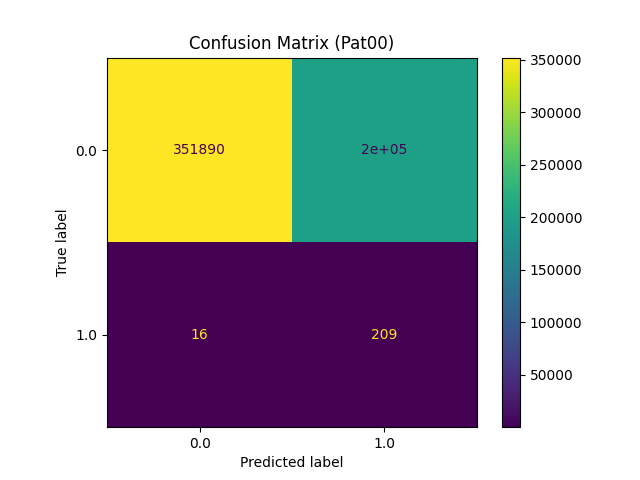

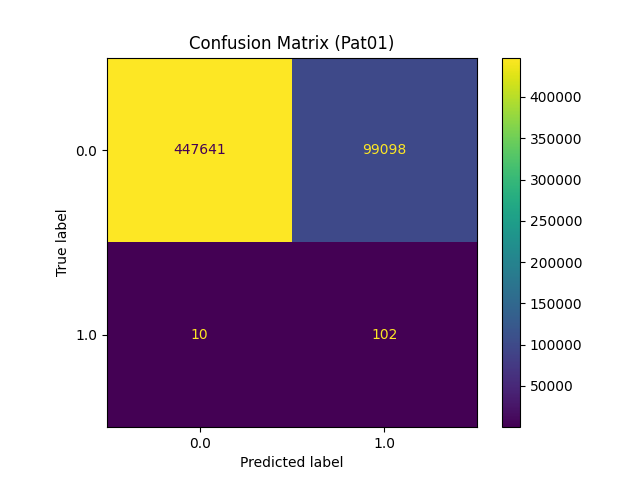

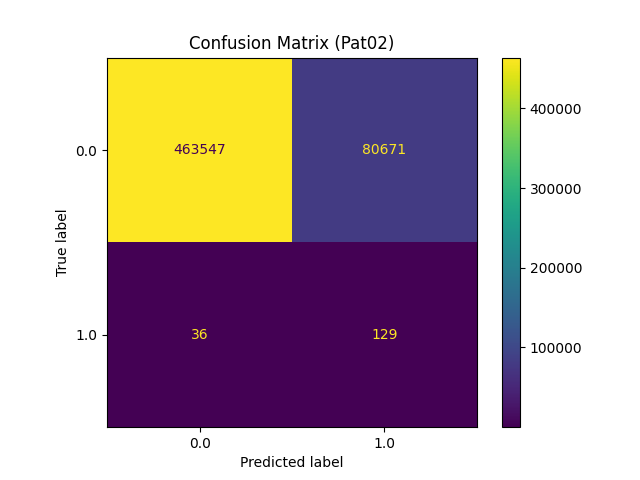

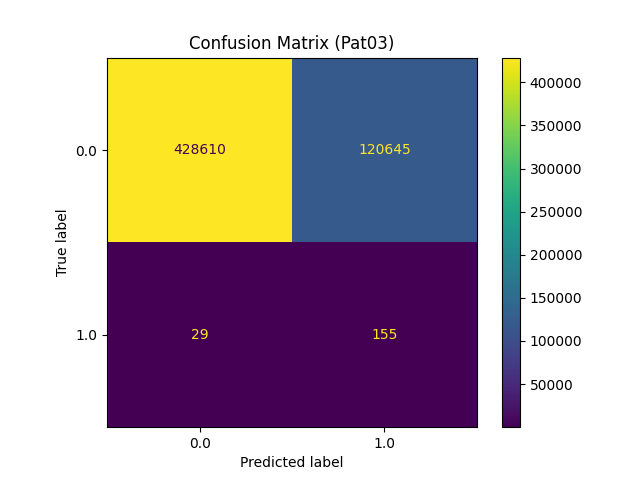

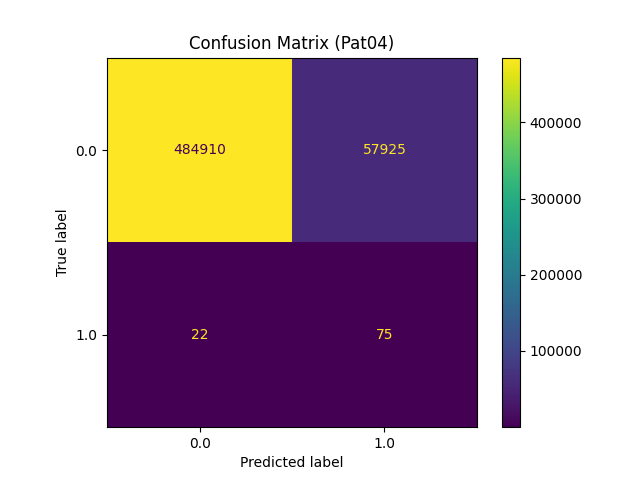

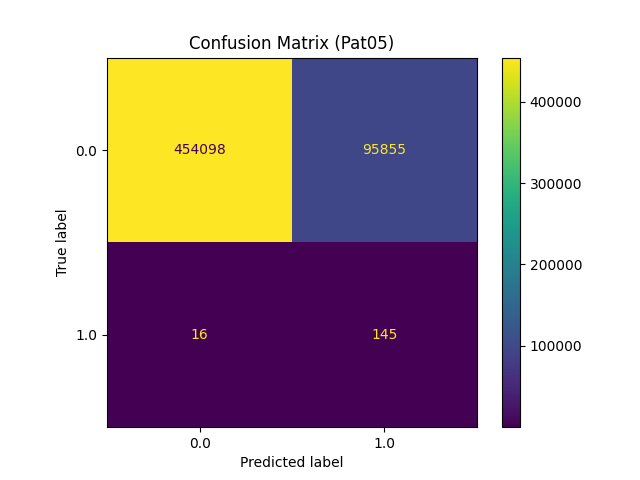

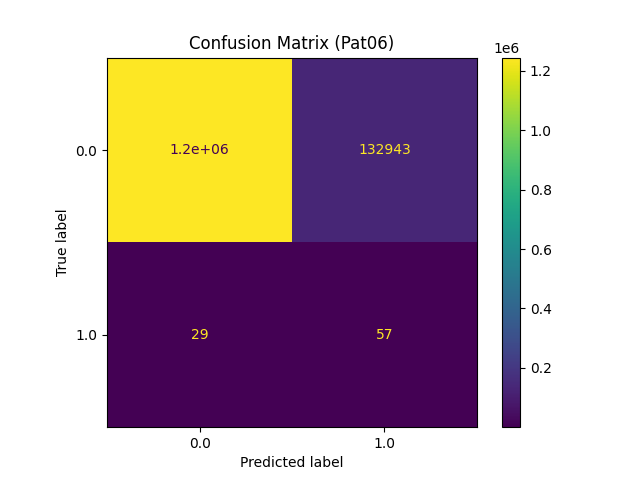

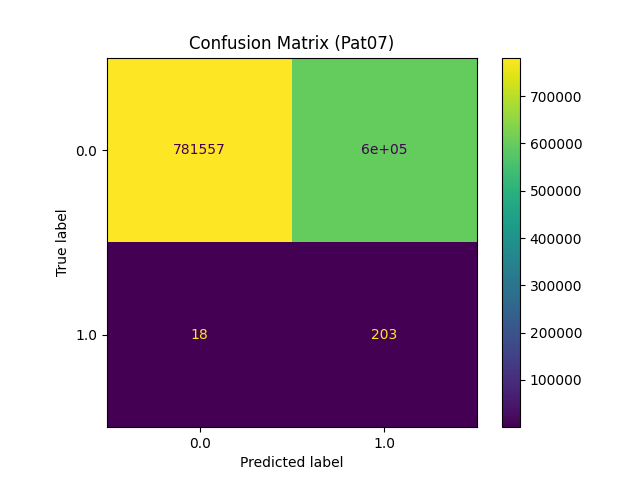

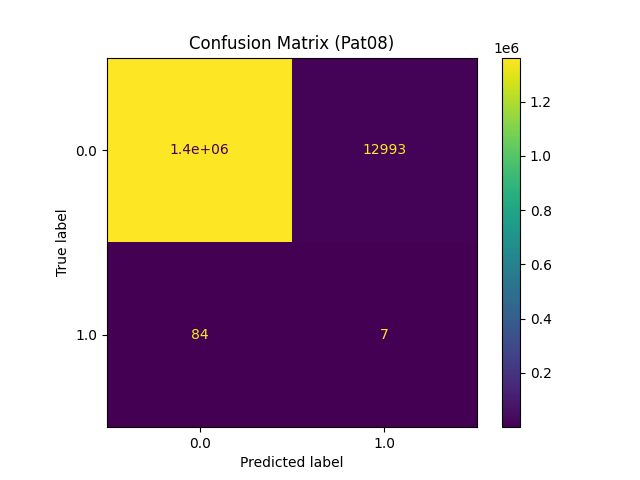

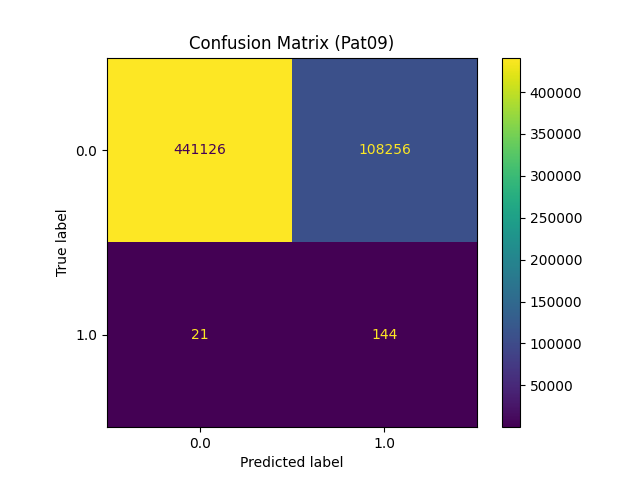

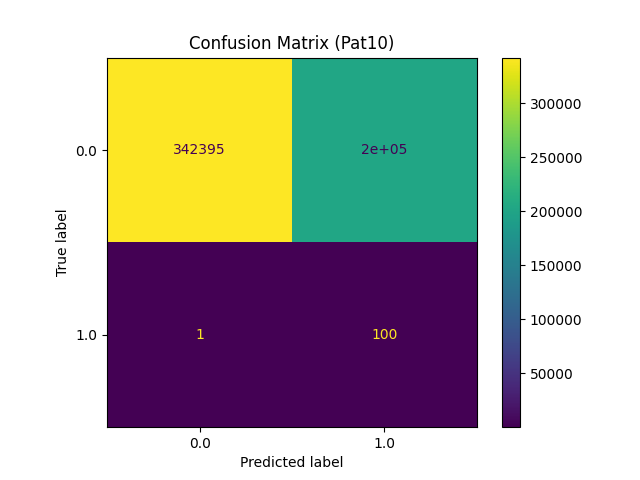

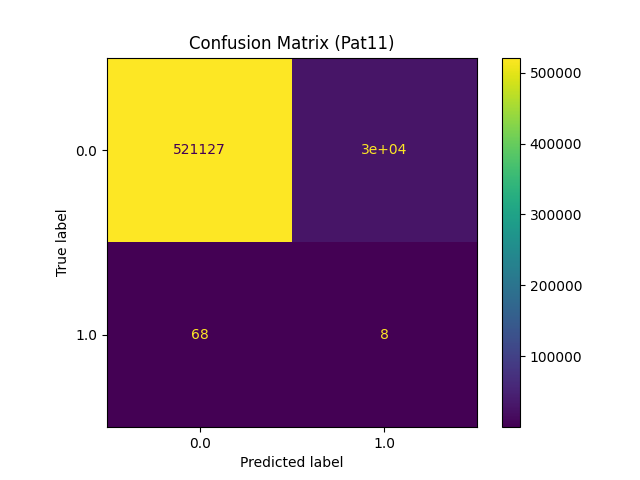

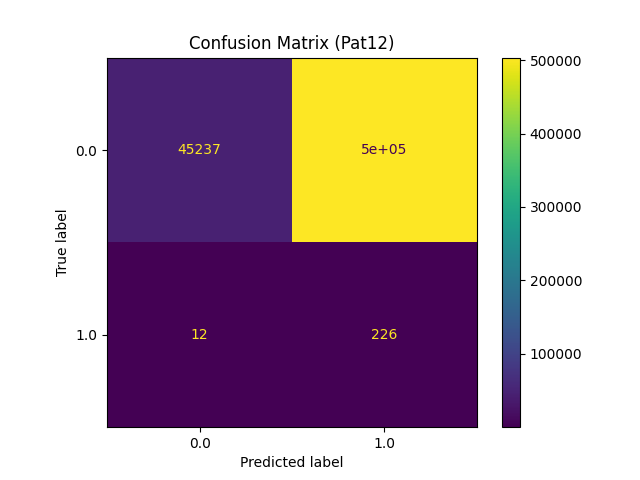

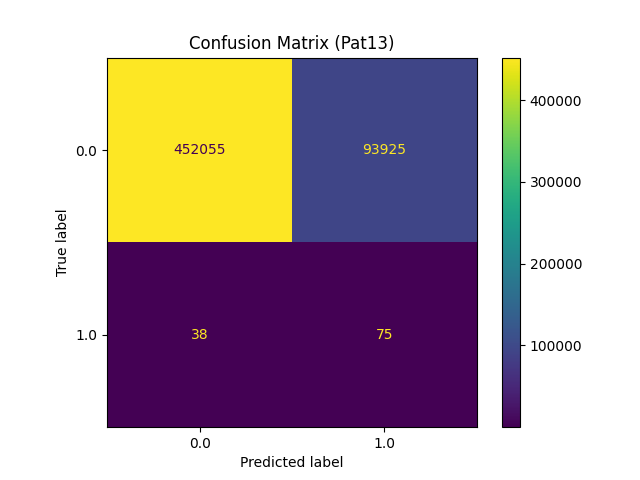

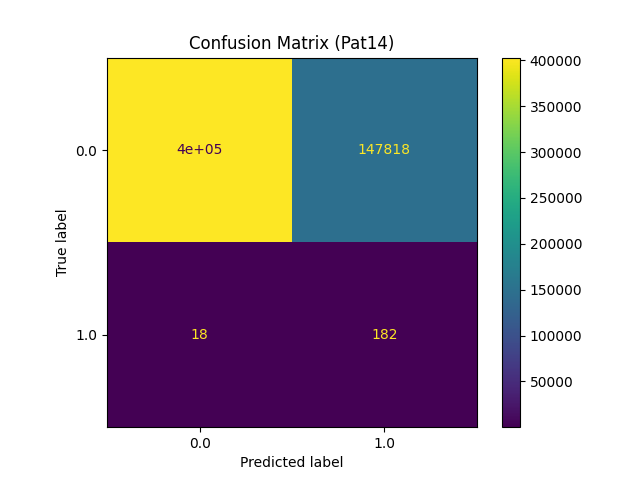

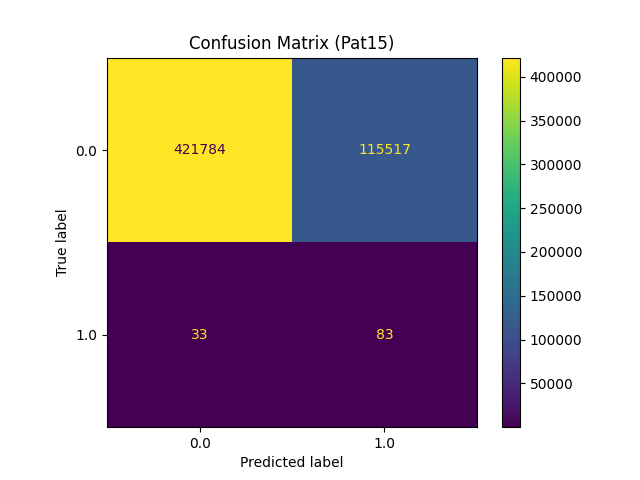

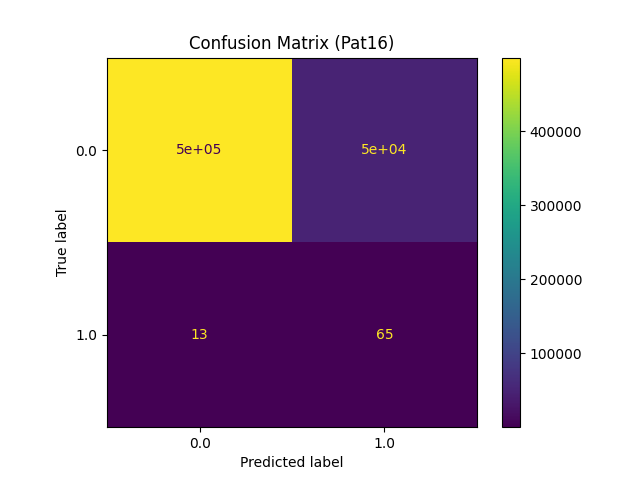

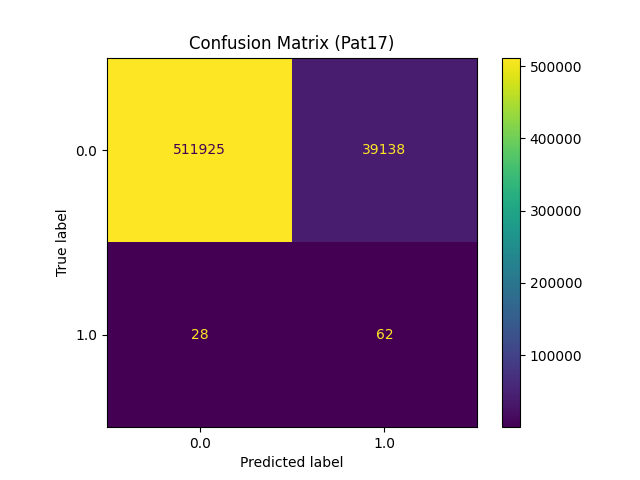

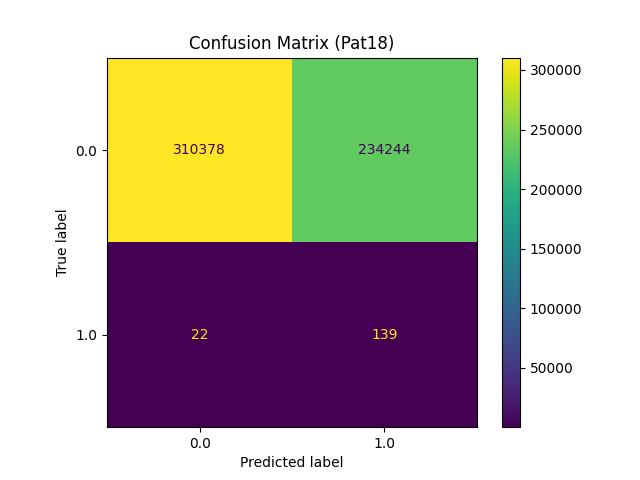

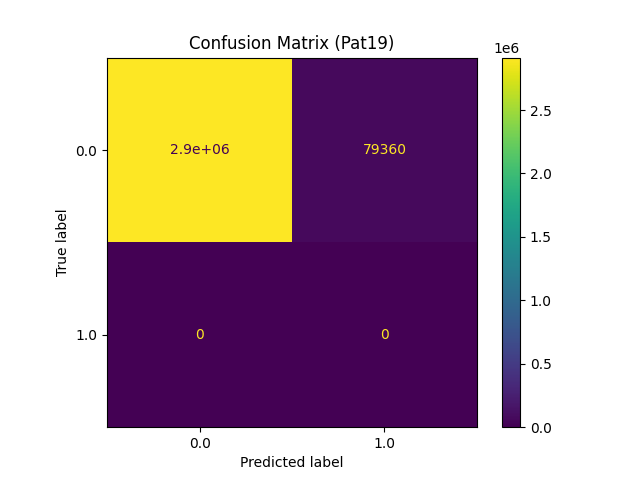

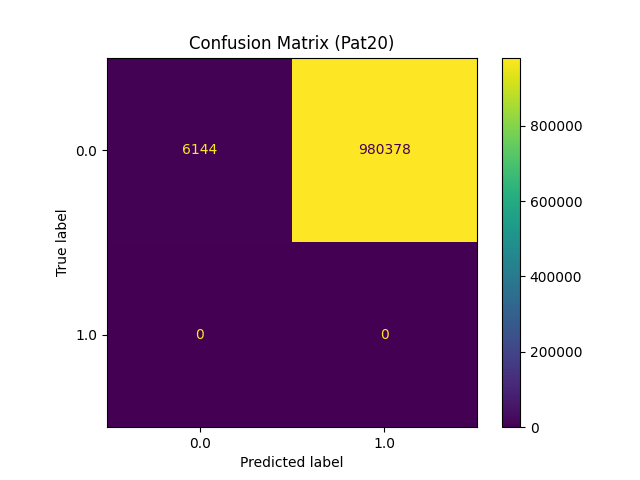

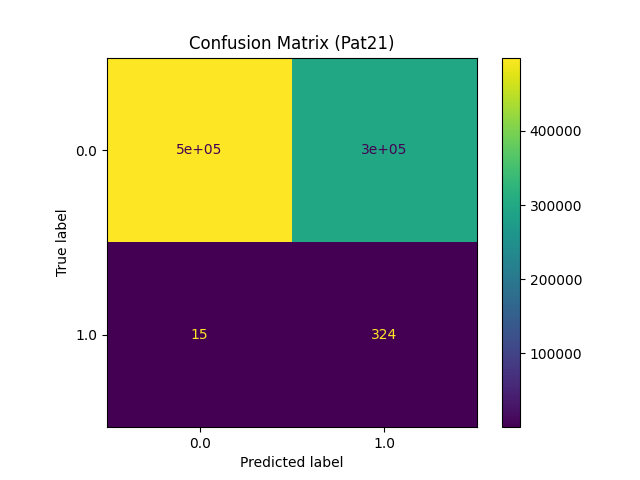

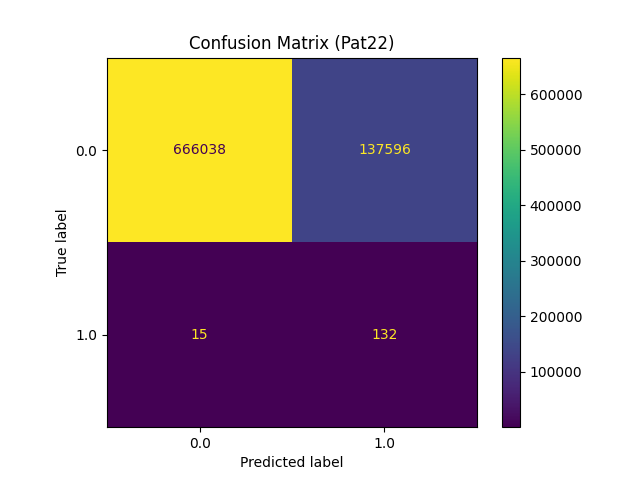

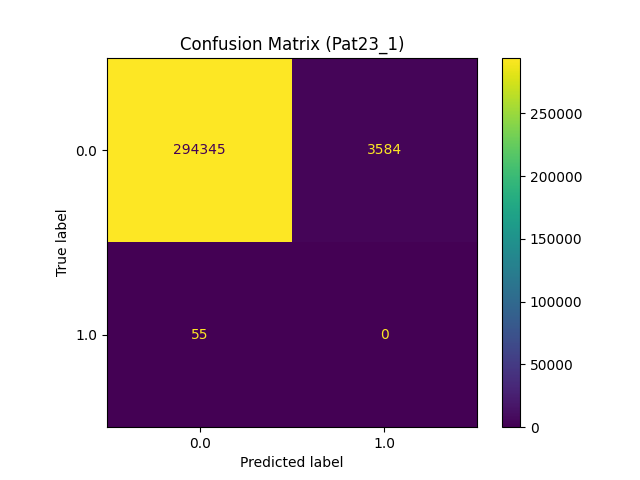

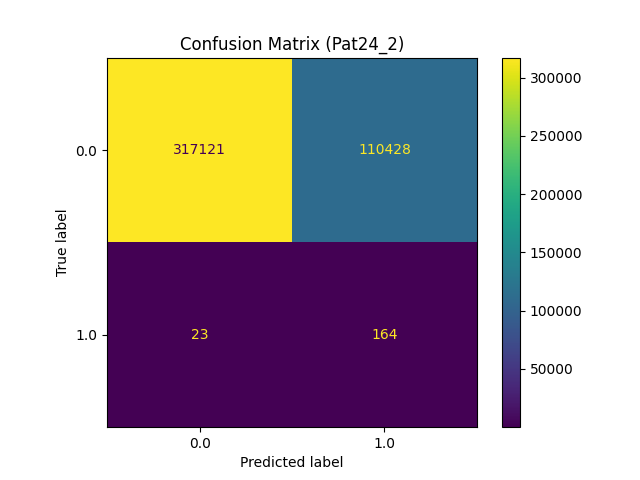

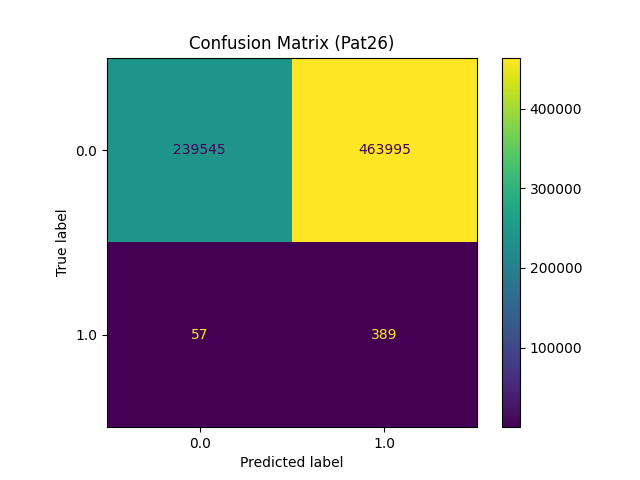

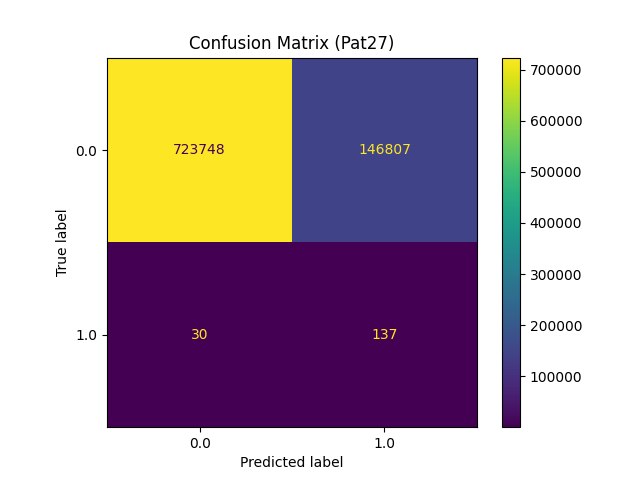

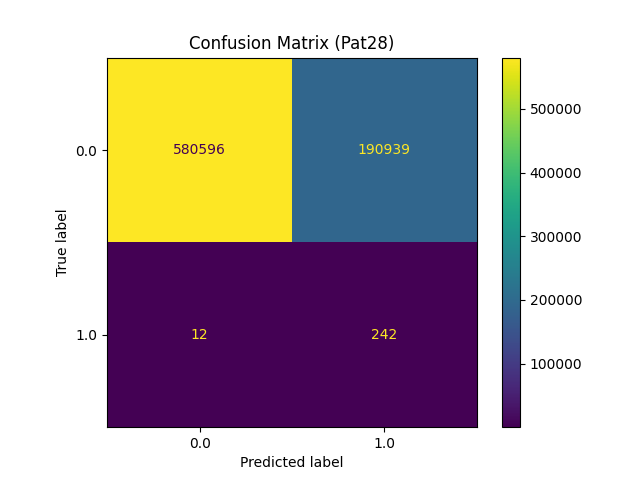

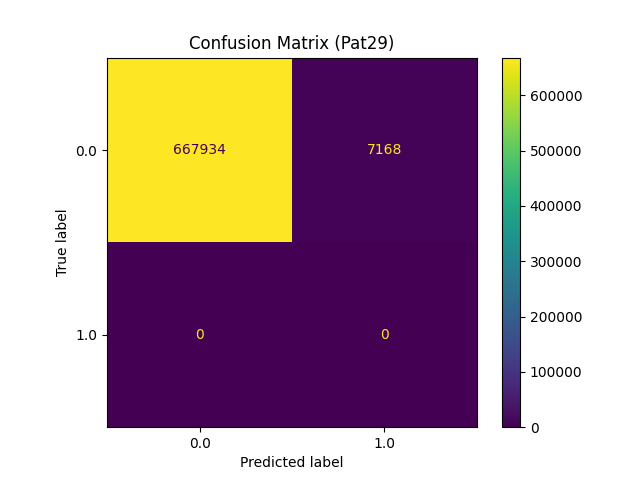

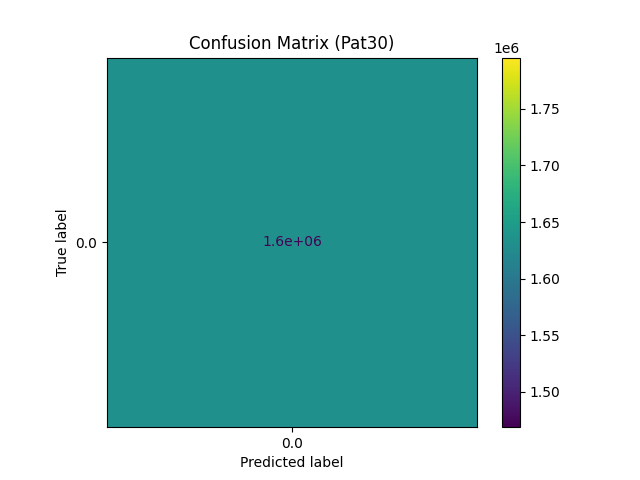

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    # Check if the arrays have the same length
    if len(labels_true) != len(labels_predicted):
        print(f"Error: Arrays have different lengths for patient {patient_id}")
        continue

    # Compute the confusion matrix
    cf = ConfusionMatrixDisplay.from_predictions(labels_true, labels_predicted)

    # Round the outputs within the matrix
    cf.ax_.set_title(f"Confusion Matrix ({patient_id})")

    # Print the confusion matrix
    print(f"Confusion matrix for patient {patient_id}:")
    print(cf)

In [ ]:
from sklearn.metrics import confusion_matrix

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    # Compute the confusion matrix
    cm = confusion_matrix(labels_true, labels_predicted)

    # Print the confusion matrix
    print(f"Confusion matrix for patient {patient_id}:")
    print(cm)

Confusion matrix for patient Pat00:
[[351890 200591]
 [    16    209]]
Confusion matrix for patient Pat01:
[[447641  99098]
 [    10    102]]
Confusion matrix for patient Pat02:
[[463547  80671]
 [    36    129]]
Confusion matrix for patient Pat03:
[[428610 120645]
 [    29    155]]
Confusion matrix for patient Pat04:
[[484910  57925]
 [    22     75]]
Confusion matrix for patient Pat05:
[[454098  95855]
 [    16    145]]
Confusion matrix for patient Pat06:
[[1244632  132943]
 [     29      57]]
Confusion matrix for patient Pat07:
[[781557 597797]
 [    18    203]]
Confusion matrix for patient Pat08:
[[1361843   12993]
 [     84       7]]
Confusion matrix for patient Pat09:
[[441126 108256]
 [    21    144]]
Confusion matrix for patient Pat10:
[[342395 203100]
 [     1    100]]
Confusion matrix for patient Pat11:
[[521127  30392]
 [    68      8]]
Confusion matrix for patient Pat12:
[[ 45237 503374]
 [    12    226]]
Confusion matrix for patient Pat13:
[[452055  93925]
 [    38     75]

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


#### TO DO: Save 'detector results' in data folder

In [ ]:
def save_results_as_parquet(results_dict, base_folder):
    for patient_id, results in results_dict.items():
        # Assuming 'results' can be directly converted to a DataFrame
        # You might need to adjust this part if 'results' requires preprocessing
        df = pd.DataFrame(results)
        
        # Construct the filename and path
        filename = f"{patient_id}-detector_results.parquet"
        filepath = f"{base_folder}/data/{filename}"
        
        # Save the DataFrame as a Parquet file
        df.to_parquet(filepath, index=False)


base_folder = "/burst-suppression-carlos/data/detector_results"  # Adjust this to your base folder path
save_results_as_parquet(results_for_analysis, base_folder)

In [45]:
results_for_analysis_df = pd.DataFrame(results_for_analysis).T
results_for_analysis_df['patient_id'] = results_for_analysis_df.index
results_for_analysis_df.reset_index(drop=True, inplace=True)
results_for_analysis_df = results_for_analysis_df[['patient_id'] + [col for col in results_for_analysis_df.columns if col != 'patient_id']]
print(results_for_analysis_df)

   patient_id                                        predictions  \
0       Pat00  [0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, ...   
1       Pat01  [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...   
2       Pat02  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...   
3       Pat03  [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, ...   
4       Pat04  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...   
5       Pat05  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
6       Pat06  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
7       Pat07  [1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, ...   
8       Pat08  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
9       Pat09  [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
10      Pat10  [0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, ...   
11      Pat11  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
12      Pat12  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
13      Pat13  [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,

#### Calculate AUROC 

get the ground truth labels from `testing_data['ground_truth']`

In [ ]:
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(true_labels, predicted_scores)
auroc = auc(fpr, tpr)
print(f"AUROC: {auroc:.2f}")

In [81]:
from sklearn.metrics import roc_auc_score

auroc_scores = {}

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    try:
        auroc = roc_auc_score(labels_true, labels_predicted) 
    except ValueError as e:
        if "Only one class present in y_true" in str(e):
            print(f"Only one class present in y_true. ROC AUC score is not defined in that case.")
            print(f"Warning: Skipping ROC AUC calculation for Patient {patient_id}")
            continue
        else:
            raise  # Re-raise the exception if it's not the specific ValueError we're handling

    auroc_scores[patient_id] = round(auroc, 2) 

Only one class present in y_true. ROC AUC score is not defined in that case.
Only one class present in y_true. ROC AUC score is not defined in that case.
Only one class present in y_true. ROC AUC score is not defined in that case.
Only one class present in y_true. ROC AUC score is not defined in that case.


In [82]:
print(auroc_scores)

{'Pat00': 0.78, 'Pat01': 0.86, 'Pat02': 0.82, 'Pat03': 0.81, 'Pat04': 0.83, 'Pat05': 0.86, 'Pat06': 0.78, 'Pat07': 0.74, 'Pat08': 0.53, 'Pat09': 0.84, 'Pat10': 0.81, 'Pat11': 0.53, 'Pat12': 0.52, 'Pat13': 0.75, 'Pat14': 0.82, 'Pat15': 0.75, 'Pat16': 0.87, 'Pat17': 0.81, 'Pat18': 0.72, 'Pat21': 0.79, 'Pat22': 0.86, 'Pat23_1': 0.49, 'Pat24_2': 0.81, 'Pat26': 0.61, 'Pat27': 0.83, 'Pat28': 0.85}


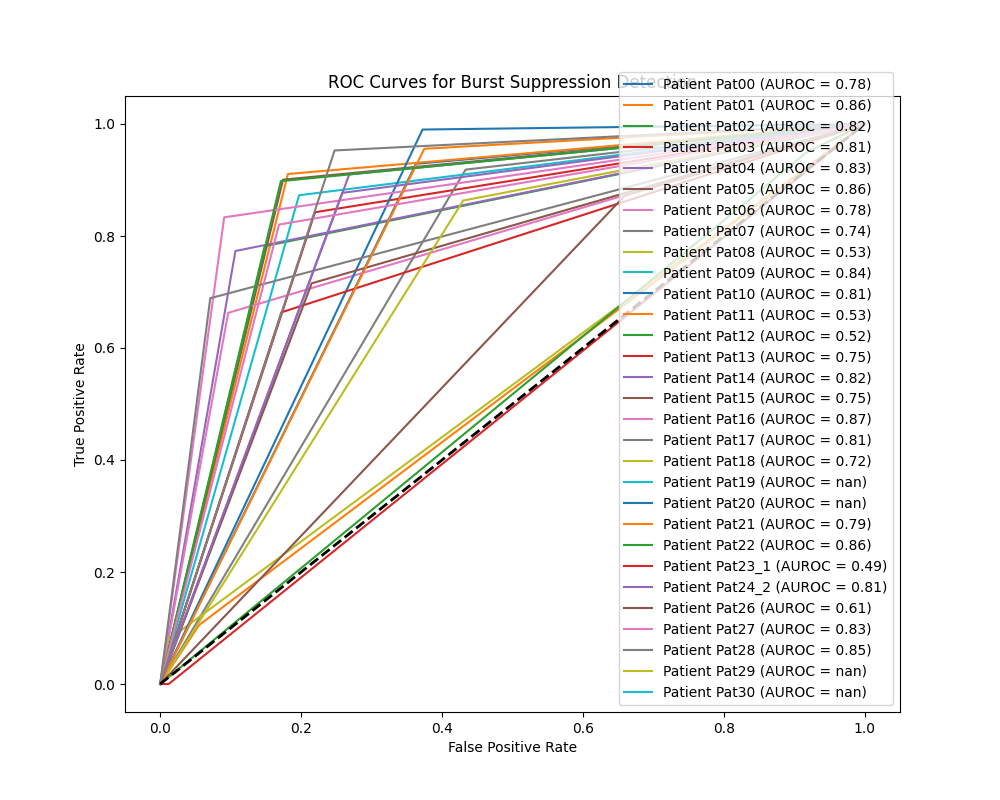

In [88]:
from sklearn.metrics import roc_curve, auc
from sklearn.exceptions import UndefinedMetricWarning
import warnings

plt.figure(figsize=(10, 8))

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UndefinedMetricWarning)
            fpr, tpr, thresholds = roc_curve(labels_true, labels_predicted)
            auroc = auc(fpr, tpr) 
            
        plt.plot(fpr, tpr, label=f'Patient {patient_id} (AUROC = {auroc:.2f})')

    except ValueError as e:
        if "Only one class present in y_true" in str(e):
            print(f"Only one class present in y_true for Patient {patient_id}. ROC AUC score is not defined.")
            # You can choose to plot a default curve or skip plotting for this patient
            # plt.plot([0, 1], [0, 1], 'k--', label=f'Patient {patient_id} (AUROC = N/A)') 
            continue
        else:
            raise  

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()

#### Calculate Burst Per Minute (BPM)
```
# Calculate Bursts Per Minute (BPM)
def calculate_bpm(data, bursts_column, window_size_seconds=2, sample_rate=200):
    total_eeg_duration = (len(data) / sample_rate / 60)
    bursts = []
    in_burst = False
    window_start_time = None

    for i, row in data.iterrows():
        if row[bursts_column] == 1 and not in_burst:
            # Start of a new burst
            in_burst = True
            window_start_time = i 
            bursts.append(i)
        elif row[bursts_column] == 0 and in_burst:
            # End of a burst
            in_burst = False
        elif in_burst and (i - window_start_time).total_seconds() >= window_size_seconds:
            # Still in a burst, but outside the current window
            in_burst = False

    total_bursts = len(bursts)

    bpm = total_bursts / total_eeg_duration
    return bpm
```

to do: 
- [ ] save calculated predictions as parquet file
- [ ] plot results for a couple of patients from patient_data dictionary
- [ ] widen ground truth by 2s
- [ ] compare results in all patients:
    - [ ] check in which direction to fill bfill() method
    - [ ] extend ground truth by fill forward ffill() method
    - [ ] visually inspect to see which direction
- [ ] calculate the difference between (.labels_ - ground_truth)=False positves and (ground_truth - labels_)=False negatives
- [ ] research literature to see validation methods; send to Jenny
- [ ] run rf on all patients
- [ ] compare clusteringdector to rf